In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

# Get data from arrayExpress: FOLFIRI time course

In [3]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16836"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    dataset='LM3'
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16836 in: ../data_arrayExpress/E-MTAB-16836
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16836
      Inferred 2 dataset representations:
      - LM2 (full prefix: Org_chemo_LM2)
      - LM3 (full prefix: Org_chemo_LM3)
      Selected dataset for in-memory loading: LM3 (full prefix: Org_chemo_LM3)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16836/E-MTAB-16836_LM2.h5ad
      Already exists, skipping rebuild: E-MTAB-16836/E-MTAB-16836_LM3.h5ad
      Loading selected dataset from disk: E-MTAB-16836/E-MTAB-16836_LM3.h5ad


AnnData object with n_obs × n_vars = 1173 × 29483
    obs: 'sample_id', 'Timepoint', 'leiden_0.5', 'HTO_classification', 'HTO_classification.global'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

Currently, wrong leiden clustering on arrayExpress. Re-do with correct resolution...

In [4]:
### Read leiden clustering from new file
obs_file = '../data/Org_chemo_LM3_metadata.txt'
obs = pd.read_csv(obs_file, sep='\t', index_col=0)
obs.head()

,sample_id,Timepoint,leiden,HTO_classification,HTO_classification.global,HTO_maxID,MUNOZ_LGR5_SIGNATURE_UCell,Lgr5_signature_UCell,Wnt_ON_signature_UCell,YAP_22_UCell,Fetal_Mustata_UCell,coreHRC_UCell
barcode,,,,,,,,,,,,
AAACGAAAGGTTGGTG-1_2,LM3,0,3,HD4347-LM3-0h,Singlet,HD4347-LM3-0h,0.019235,0.128457,0.077940,0.000000,0.063719,0.024787
AAACGAACAGTAGTGG-1_2,LM3,12,1,HD4347-LM3-12h,Singlet,HD4347-LM3-12h,0.037987,0.277822,0.094185,0.000000,0.052176,0.000000
AAACGCTCAATTCGTG-1_2,LM3,48,0,HD4347-LM3-48h,Singlet,HD4347-LM3-48h,0.027014,0.092118,0.075790,0.000000,0.082643,0.093776
AAACGCTCAGACGCTC-1_2,LM3,84,1,HD4347-LM3-72h+12h,Singlet,HD4347-LM3-72h+12h,0.023236,0.000000,0.083069,0.006672,0.059193,0.022506
AAACGCTGTATCGTGT-1_2,LM3,72,0,HD4347-LM3-72h,Singlet,HD4347-LM3-72h,0.040180,0.000000,0.064873,0.018093,0.070015,0.019752


In [5]:
# Add leiden to adata.obs
leiden_key = 'leiden'
adata.obs[leiden_key] = obs['leiden']
# make sure leiden is categorical
adata.obs[leiden_key] = pd.Categorical(adata.obs[leiden_key])
print(adata.obs.head(2))

                     sample_id  Timepoint  leiden_0.5 HTO_classification  \
AAACGAAAGGTTGGTG-1_2       LM3          0           3      HD4347-LM3-0h   
AAACGAACAGTAGTGG-1_2       LM3         12           1     HD4347-LM3-12h   

                     HTO_classification.global leiden  
AAACGAAAGGTTGGTG-1_2                   Singlet      3  
AAACGAACAGTAGTGG-1_2                   Singlet      1  


## Import dataset specifics

In [6]:
# Import magic imputation results
import utils
utils.import_magic(adata, final_id='Org_chemo_LM3_woCC')

Importing MAGIC results...
4937 missing genes will be added to magic matrix with zero counts.


In [7]:
# Add time annotation
from utils_chemo_timecourse import color_code
import utils_chemo_timecourse as utils_spec

utils_spec.add_time(adata)
utils.set_uns_colors(adata, color_code, 'time')

## UMAP representation

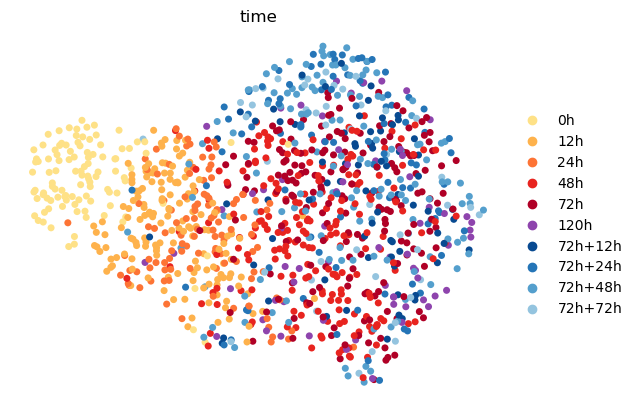

In [45]:
# Annotation UMAP
sc.pl.umap(adata, color=['time'], frameon=False, title=None)

## Gene expression UMAP (requries magic imputation)

UMAPs of gene expression patterns:


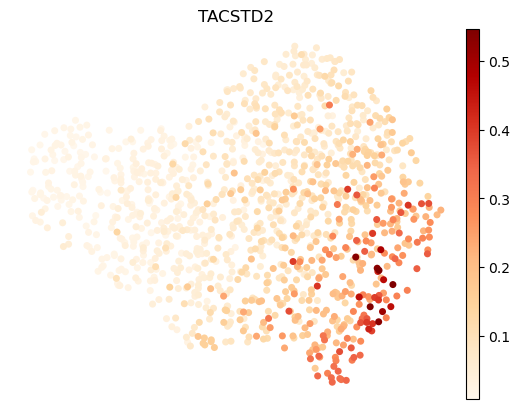

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_3362674/2859259395.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


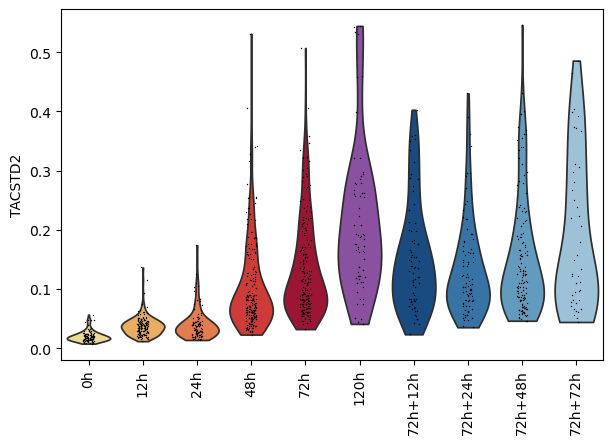

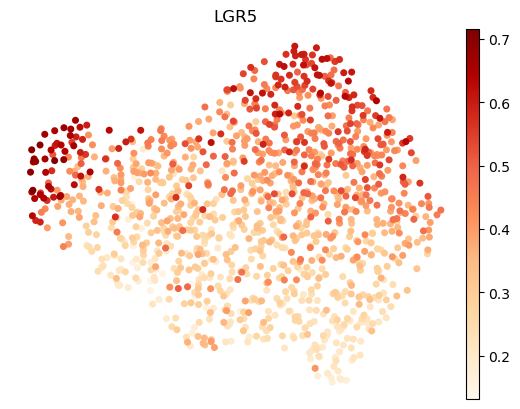

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_3362674/2859259395.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


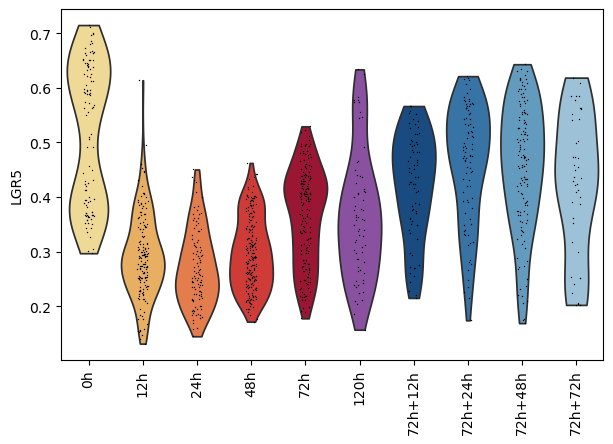

In [39]:
# Features to plot
features = ['TACSTD2', 'LGR5']

# Groupby
groupby = 'time'

# Data layer
layer = 'magic'

# Define plotting parameters
vmax = None
dot_size = 120000 / adata.shape[0]

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot on UMAP
    sc.pl.umap(adata, color=feature, 
               layer=layer, use_raw=False,
               size=dot_size, 
               cmap='OrRd', vmax=vmax, frameon=False)
    plt.tight_layout()
    plt.show()

    # Plot as violin plot
    ax = sc.pl.violin(adata, keys=feature, groupby=groupby, 
                 layer=layer, use_raw=False, rotation=90, show=False)
    if ax.legend_ is not None:
        ax.legend_.set_bbox_to_anchor((1.02, 0.9))

    plt.tight_layout()
    plt.show()

## Read palantir dataset

In [3]:
import palantir

In [4]:
dir_data = '../data/palantir/'
files = os.listdir(dir_data)
files = [f for f in files if f.endswith('.h5ad')]
files

['Org_chemo_LM3_woCC_palantir_v00.h5ad',
 'HD4246_SG_0h-48h_palantir.h5ad',
 'HD4246_SG_48-120h_palantir.h5ad',
 'SG_0h_6h_24h_48h_woCC_res0.4_cl0-6_v01_palantir.h5ad',
 'Org_chemo_LM3_palantir.h5ad',
 'SG_48h_72h_120h_woCC_v02b_palantir.h5ad']

In [5]:
file = '../data/palantir/Org_chemo_LM3_woCC_palantir_v00.h5ad'
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 1173 × 29483
    obs: 'sample_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'percent.ribo', 'mt.content', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.0.5', 'seurat_clusters', 'Timepoint', 'RNA_snn_res.1', 'Lgr5_signature_UCell', 'Wnt_ON_signature_UCell', 'Fetal_Mustata_UCell', 'coreHRC_UCell', 'YAP_22_UCell', 'Fetal_Karuna_UCell', 'Apoptosis_Initiation_UCell', 'Cell_Quiescence_UCell', 'Cell_Proliferation_UCell', 'Intestinal_Enterocytes_Absorptive_UCell', 'Intestinal_Goblet_Cells_UCell', 'Intestinal_Paneth_Cells_UCell', 'Intestinal_Enteroendocrine_Cells_UCell', 'Intestinal_Tuft_Cells_UCell', 'Epithelial_Mesenchymal_Transition_UCell', 'Hypoxia_Response_UCell', 'Drug_Metabolism_Phase_I_UCell', 'Drug_Metabolism_Phase_II_UCell', 'Drug_Metabolism_Phase_III_Transporters_UCell', 'FOLFIRI_5FU_Metabolism_and_Target_UCell'

### Plotting palantir results

In [6]:
from utils_chemo_timecourse import color_code

In [7]:
# Pick branch color from color code
branches = ['Term_0', 'Term_2']
branch_color = {
    'Term_0': color_code['time']['colors']['72h'],
    'Term_2': color_code['time']['colors']['72h+12h']
}
# Mapping of interpretable branch names
branch_title = {
    "Term_0": "Treatment",
    "Term_2": "Release"
}

[2026-04-27 21:30:49,885] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (453) and rank = 1.0.
[2026-04-27 21:30:49,886] [INFO    ] Using covariance function Matern52(ls=0.6709485054016113).
[2026-04-27 21:30:49,886] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-04-27 21:30:50,457] [INFO    ] Sigma interpreted as element-wise standard deviation.
[2026-04-27 21:30:50,583] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (370) and rank = 1.0.
[2026-04-27 21:30:50,583] [INFO    ] Using covariance function Matern52(ls=0.6709485054016113).
[2026-04-27 21:30:50,584] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-04-27 21:30:51,249] [INFO    ] Sigma interpreted as element-wise standard deviation.


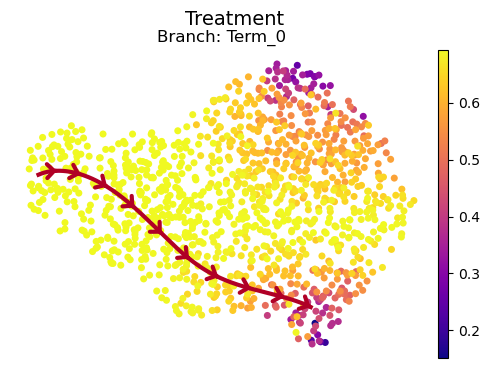

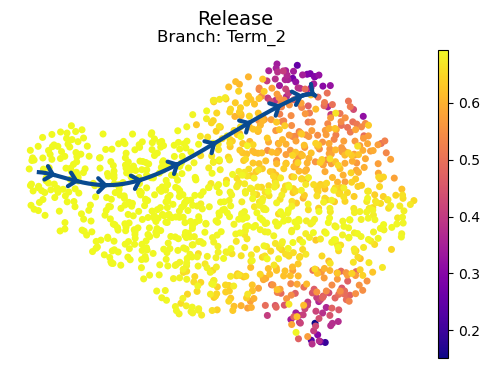

In [ ]:
# Palantir branches on UMAP
entropy_cmap = 'plasma'

# Make UMAP plot for each branch
for branch in branches:
    color = 'palantir_entropy'
    palantir.plot.plot_trajectory(
        adata,
        branch, 
        cell_color="palantir_entropy", 
        n_arrows=10, 
        color=branch_color[branch], 
        scanpy_kwargs=dict(cmap=entropy_cmap), 
        arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3),
        lw=3, 
        pseudotime_interval=(0, .9), 
    )
    fig = plt.gcf()
    fig.set_size_inches(6, 4)
    fig.suptitle(branch_title[branch], fontsize=14)
    fig.show()

In [9]:
# Compute gene trends
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

Term_0
[2026-04-27 21:25:57,464] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (500) >= n_samples (453) and rank = 1.0.
[2026-04-27 21:25:57,465] [INFO    ] Using covariance function Matern52(ls=1.0).


[2026-04-27 21:25:58,565] [INFO    ] Sigma interpreted as element-wise standard deviation.
Term_2
[2026-04-27 21:26:01,266] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (500) >= n_samples (370) and rank = 1.0.
[2026-04-27 21:26:01,267] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-04-27 21:26:01,863] [INFO    ] Sigma interpreted as element-wise standard deviation.


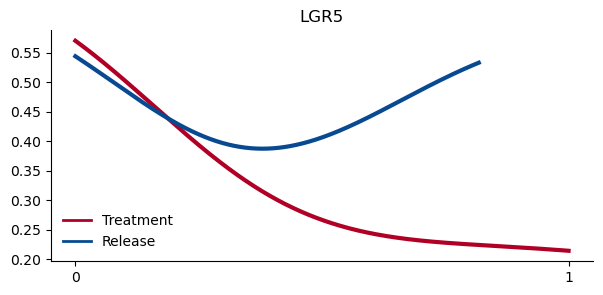

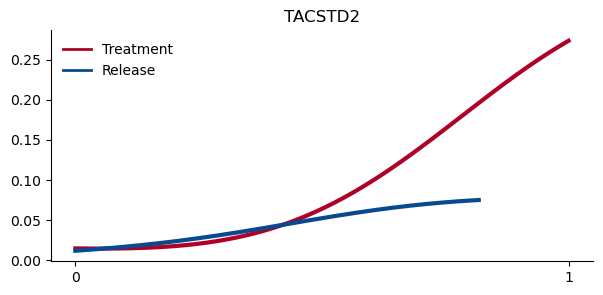

In [10]:
# Visualize gene trends
from matplotlib.lines import Line2D

# Visualize individual genes across branches
genes = ["LGR5", "TACSTD2"]

# Iterate over all genes
for gene in genes:
    # Get palantir figure output
    fig  = palantir.plot.plot_gene_trends(adata, [gene])
    # Get all axes in the figure
    for ax in fig.axes:
        for line in ax.get_lines():
            label = line.get_label()
            # Set line color and width based on branch
            for br, col in branch_color.items():
                if br in label:
                    line.set_color(col)
                    line.set_linewidth(3.0)

    # Extract legend handles and labels for custom legend
    legend_handles = [
        Line2D(
            [0], [0],
            color=branch_color[br],
            lw=2,
            label=branch_title[br]
        )
        for br in branches
    ]

    # Add custom legend to each axis
    for ax in fig.axes:
        ax.legend(
            handles=legend_handles,
            title="",
            frameon=False
        )
    fig = plt.gcf()
    fig.canvas.draw_idle()
    fig.show()